# Module 2 — Body Segmentation
### Virtual Fashion Fitting Room

**What this module does:**
- Generates a precise body segmentation mask using SAM
- Parses the body into semantic regions (skin, hair, upper clothes, lower clothes) using a HuggingFace SegFormer model
- Produces the **clothing-agnostic person image** — the core input to the cGAN

**Inputs** (from Module 1):
- Person image
- Keypoints JSON
- Pose heatmaps

**Outputs:**
- `*_body_mask.png` — precise person boundary mask
- `*_parse.png` — human parsing map (colour-coded regions)
- `*_agnostic.jpg` — clothing-agnostic person image
- `*_agnostic_mask.png` — binary mask of erased clothing region

---

## Step 1 — Install additional dependencies

In [1]:
# Run once — the transformers library gives us the human parsing model
!pip install transformers accelerate

  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 14.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 11.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 14.1 MB/s  0:00:00 eta 0:00:01
Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl (3.0 MB)
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [transformer

## Step 2 — Imports

In [2]:
import cv2
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

# SAM
from segment_anything import sam_model_registry, SamPredictor

# HuggingFace — SegFormer for human parsing
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.10.0


## Step 3 — Human parsing label map

We use `mattmdjaga/segformer_b2_clothes` — a SegFormer model fine-tuned on the ATR dataset.  
It classifies every pixel into one of these clothing/body categories:

In [3]:
# ATR dataset label mapping
ATR_LABELS = {
    0:  'background',
    1:  'hat',
    2:  'hair',
    3:  'sunglasses',
    4:  'upper_clothes',   # ← this is what we erase for upper garment try-on
    5:  'skirt',
    6:  'pants',
    7:  'dress',
    8:  'belt',
    9:  'left_shoe',
    10: 'right_shoe',
    11: 'face',
    12: 'left_leg',
    13: 'right_leg',
    14: 'left_arm',
    15: 'right_arm',
    16: 'bag',
    17: 'scarf'
}

# Colour map for visualisation (RGB)
ATR_COLORS = {
    0:  (0,   0,   0),    # background — black
    1:  (128, 0,   0),    # hat
    2:  (255, 200, 50),   # hair — amber
    3:  (0,   128, 128),  # sunglasses
    4:  (255, 80,  80),   # upper clothes — red (what we erase)
    5:  (80,  80,  255),  # skirt
    6:  (80,  80,  255),  # pants
    7:  (180, 80,  255),  # dress
    8:  (128, 64,  0),    # belt
    9:  (100, 100, 100),  # left shoe
    10: (150, 150, 150),  # right shoe
    11: (255, 180, 140),  # face — skin tone
    12: (100, 200, 100),  # left leg
    13: (80,  160, 80),   # right leg
    14: (100, 180, 255),  # left arm
    15: (80,  140, 255),  # right arm
    16: (200, 150, 50),   # bag
    17: (200, 200, 200),  # scarf
}

# Which labels to erase for upper-body garment try-on
UPPER_GARMENT_LABELS = {4, 7, 17}  # upper_clothes, dress, scarf

print(f"Total ATR labels  : {len(ATR_LABELS)}")
print(f"Labels to erase   : {[ATR_LABELS[l] for l in UPPER_GARMENT_LABELS]}")

Total ATR labels  : 18
Labels to erase   : ['scarf', 'upper_clothes', 'dress']


## Step 4 — Load models

In [6]:
# ── SAM ──────────────────────────────────────────────────────────────────────
SAM_CHECKPOINT = "checkpoints/sam_vit_h_4b8939.pth"
SAM_MODEL_TYPE = "vit_h"

print("Loading SAM...")
sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to(DEVICE)
sam_predictor = SamPredictor(sam)
print("SAM loaded ✓")

# ── SegFormer human parser ────────────────────────────────────────────────────
# Downloads ~180 MB on first run, cached locally after that
PARSER_MODEL = "mattmdjaga/segformer_b2_clothes"

print("\nLoading SegFormer human parser (downloads on first run)...")
parse_processor = SegformerImageProcessor.from_pretrained(PARSER_MODEL)
parse_model     = SegformerForSemanticSegmentation.from_pretrained(PARSER_MODEL)
parse_model.to(DEVICE)
parse_model.eval()
print("Human parser loaded ✓")

Loading SAM...
SAM loaded ✓

Loading SegFormer human parser (downloads on first run)...


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/Users/purveshg/anaconda3/envs/vfr-env/lib/python3.10/site-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Human parser loaded ✓


## Step 5 — BodySegmentor class

In [11]:
class BodySegmentor:
    """
    Full body segmentation pipeline.

    Given a person image and its pose keypoints, produces:
      1. Precise body mask (SAM)
      2. Human parse map (SegFormer)
      3. Clothing-agnostic person image
      4. Agnostic region mask
    """

    def __init__(self, sam_predictor, parse_processor, parse_model, device='cpu'):
        self.sam        = sam_predictor
        self.processor  = parse_processor
        self.parse_model= parse_model
        self.device     = device

    # ── Part A: SAM body segmentation ────────────────────────────────────────
    def get_body_mask(self, image_rgb, keypoints, conf_threshold=0.3):
        """
        Use SAM with pose keypoints as prompts to get a precise body mask.

        SAM is prompted with the high-confidence body keypoints — this is far
        more accurate than a simple background subtraction approach.

        Args:
            image_rgb   : (H, W, 3) RGB numpy array
            keypoints   : list of 18 (x, y, conf) tuples from Module 1
            conf_threshold: min confidence to use as SAM prompt

        Returns:
            body_mask   : (H, W) binary uint8 mask — 255 = person, 0 = background
        """
        # Build point prompts from confident keypoints
        prompt_points = []
        prompt_labels = []

        for (x, y, conf) in keypoints:
            if conf >= conf_threshold and x > 0 and y > 0:
                prompt_points.append([x, y])
                prompt_labels.append(1)  # 1 = foreground point

        if len(prompt_points) == 0:
            print("WARNING: No confident keypoints for SAM prompt. Using image centre.")
            h, w = image_rgb.shape[:2]
            prompt_points = [[w // 2, h // 2]]
            prompt_labels = [1]

        # Set image in SAM predictor
        self.sam.set_image(image_rgb)

        # Predict — SAM returns up to 3 mask candidates; we take the best one
        masks, scores, _ = self.sam.predict(
            point_coords=np.array(prompt_points),
            point_labels=np.array(prompt_labels),
            multimask_output=True
        )

        # Pick the mask with the highest SAM confidence score
        best_idx  = np.argmax(scores)
        best_mask = masks[best_idx].astype(np.uint8) * 255

        # Morphological cleanup — fill small holes, remove stray pixels
        kernel    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_CLOSE, kernel)
        best_mask = cv2.morphologyEx(best_mask, cv2.MORPH_OPEN,  kernel)

        return best_mask

    # ── Part B: Human parsing ────────────────────────────────────────────────
    def get_parse_map(self, image_pil):
        """
        Run SegFormer to classify every pixel into a body/clothing region.

        Args:
            image_pil: PIL Image (RGB)

        Returns:
            parse_map : (H, W) uint8 array with ATR label indices
        """
        orig_w, orig_h = image_pil.size

        # Preprocess for SegFormer
        inputs = self.processor(images=image_pil, return_tensors="pt")
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        # Inference
        with torch.no_grad():
            outputs = self.parse_model(**inputs)

        # Upsample logits back to original image size
        logits_upsampled = torch.nn.functional.interpolate(
            outputs.logits,
            size=(orig_h, orig_w),
            mode='bilinear',
            align_corners=False
        )

        # Argmax to get per-pixel label
        parse_map = logits_upsampled.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)
        return parse_map

    # ── Part C: Clothing-agnostic image ──────────────────────────────────────
    def get_agnostic_image(self, image_rgb, parse_map, keypoints,
                           erase_labels=UPPER_GARMENT_LABELS,
                           conf_threshold=0.3):
        """
        Generate the clothing-agnostic person image.

        Strategy:
          1. Build an erase mask from parse_map (clothing region)
          2. Expand the mask slightly to avoid garment edge artifacts
          3. Fill erased region with neutral grey
          4. Preserve everything else: face, hair, arms, legs, background

        Args:
            image_rgb    : (H, W, 3) RGB numpy array
            parse_map    : (H, W) uint8 ATR label map
            keypoints    : list of 18 (x, y, conf) tuples
            erase_labels : set of ATR label indices to erase

        Returns:
            agnostic_img : (H, W, 3) RGB agnostic image
            agnostic_mask: (H, W) uint8 binary mask — 255 = erased region
        """
        h, w = image_rgb.shape[:2]

        # Build clothing erase mask
        erase_mask = np.zeros((h, w), dtype=np.uint8)
        for label_id in erase_labels:
            erase_mask[parse_map == label_id] = 255

        # Also erase arms if they are inside the clothing region
        # (arms sticking out of sleeves should stay visible)
        # Strategy: keep arm pixels that are below the shoulder keypoints
        r_shoulder = keypoints[2]  # right shoulder
        l_shoulder = keypoints[5]  # left shoulder

        if r_shoulder[2] >= conf_threshold and l_shoulder[2] >= conf_threshold:
            shoulder_y = int((r_shoulder[1] + l_shoulder[1]) / 2)
            # Only erase arm pixels that are above the shoulder line
            # (these are armpits/shoulder area that should be covered)
            arm_mask = np.zeros((h, w), dtype=np.uint8)
            arm_mask[(parse_map == 14) | (parse_map == 15)] = 255  # left+right arm
            arm_mask[shoulder_y:, :] = 0  # keep arms below shoulder
            erase_mask = cv2.bitwise_or(erase_mask, arm_mask)

        # Dilate mask slightly to cover garment edges cleanly
        kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        erase_mask = cv2.dilate(erase_mask, kernel, iterations=1)

        # Fill erased region with neutral grey (128, 128, 128)
        agnostic = image_rgb.copy()
        agnostic[erase_mask == 255] = [128, 128, 128]

        return agnostic, erase_mask

    # ── Full pipeline ─────────────────────────────────────────────────────────
    def process(self, image_path, keypoints):
        """
        Run the full segmentation pipeline on one image.

        Args:
            image_path : str or Path
            keypoints  : list of 18 (x, y, conf) from Module 1 JSON

        Returns:
            dict with all outputs
        """
        # Load image in both formats we need
        img_bgr  = cv2.imread(str(image_path))
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_pil  = Image.fromarray(img_rgb)

        print(f"Processing: {Path(image_path).name}  ({img_rgb.shape[1]}x{img_rgb.shape[0]})")

        # Part A — SAM body mask
        print("  ► SAM body segmentation...")
        body_mask = self.get_body_mask(img_rgb, keypoints)

        # Part B — Human parsing
        print("  ► Human parsing (SegFormer)...")
        parse_map = self.get_parse_map(img_pil)

        # Mask parse map to person region only (ignore background parse errors)
        parse_map[body_mask == 0] = 0

        # Part C — Agnostic image
        print("  ► Generating agnostic image...")
        agnostic_img, agnostic_mask = self.get_agnostic_image(
            img_rgb, parse_map, keypoints
        )

        print("  ✓ Done")

        return {
            'image_rgb':     img_rgb,
            'body_mask':     body_mask,
            'parse_map':     parse_map,
            'agnostic_img':  agnostic_img,
            'agnostic_mask': agnostic_mask,
        }

print("BodySegmentor class defined.")

BodySegmentor class defined.


## Step 6 — Helper: load keypoints from Module 1 JSON

In [8]:
def load_keypoints_from_json(json_path):
    """
    Load keypoints from the HR-VITON format JSON saved by Module 1.

    Returns:
        list of 18 (x, y, conf) tuples
    """
    with open(json_path) as f:
        data = json.load(f)

    flat = data['people'][0]['pose_keypoints_2d']

    # Un-flatten [x0, y0, c0, x1, y1, c1, ...] → [(x0,y0,c0), ...]
    keypoints = [
        (int(flat[i]), int(flat[i+1]), float(flat[i+2]))
        for i in range(0, len(flat), 3)
    ]
    return keypoints


def parse_map_to_color(parse_map):
    """
    Convert integer parse map to an RGB colour image for visualisation.
    """
    h, w    = parse_map.shape
    color   = np.zeros((h, w, 3), dtype=np.uint8)
    for label_id, rgb in ATR_COLORS.items():
        color[parse_map == label_id] = rgb
    return color


def show_segmentation_results(result):
    """
    Display a 4-panel summary of all segmentation outputs.
    """
    parse_color = parse_map_to_color(result['parse_map'])

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(result['image_rgb'])
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(result['body_mask'], cmap='gray')
    axes[1].set_title('SAM body mask')
    axes[1].axis('off')

    axes[2].imshow(parse_color)
    axes[2].set_title('Human parse map')
    axes[2].axis('off')

    axes[3].imshow(result['agnostic_img'])
    axes[3].set_title('Agnostic image')
    axes[3].axis('off')

    # Legend for parse map
    patches = [
        mpatches.Patch(color=np.array(ATR_COLORS[i])/255, label=ATR_LABELS[i])
        for i in sorted(ATR_COLORS.keys())
        if ATR_LABELS[i] != 'background'
    ]
    fig.legend(handles=patches, loc='lower center', ncol=9, fontsize=7, framealpha=0.5)

    plt.tight_layout()
    plt.show()

    # Print region breakdown
    total_pixels = result['parse_map'].size
    print("\nRegion breakdown:")
    print(f"  {'Region':<20} {'Pixels':>8}  {'Coverage':>8}")
    print("  " + "-" * 40)
    for label_id, name in ATR_LABELS.items():
        count = np.sum(result['parse_map'] == label_id)
        if count > 0:
            pct = count / total_pixels * 100
            print(f"  {name:<20} {count:>8}   {pct:>6.1f}%")

print("Helper functions defined.")

Helper functions defined.


## Step 7 — Run on test image

In [12]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────
TEST_IMAGE_PATH  = "data/test-image.jpg"                        # same image as Module 1
POSE_JSON_PATH   = "outputs/pose/test-image_keypoints.json"  # from Module 1
OUTPUT_DIR       = Path("outputs/segmentation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────

# Load keypoints from Module 1
keypoints = load_keypoints_from_json(POSE_JSON_PATH)
print(f"Loaded {len(keypoints)} keypoints from Module 1 JSON")

# Initialise segmentor
segmentor = BodySegmentor(
    sam_predictor  = sam_predictor,
    parse_processor= parse_processor,
    parse_model    = parse_model,
    device         = DEVICE
)

# Run full pipeline
result = segmentor.process(TEST_IMAGE_PATH, keypoints)

Loaded 18 keypoints from Module 1 JSON
Processing: test-image.jpg  (4912x7360)
  ► SAM body segmentation...
  ► Human parsing (SegFormer)...
  ► Generating agnostic image...
  ✓ Done


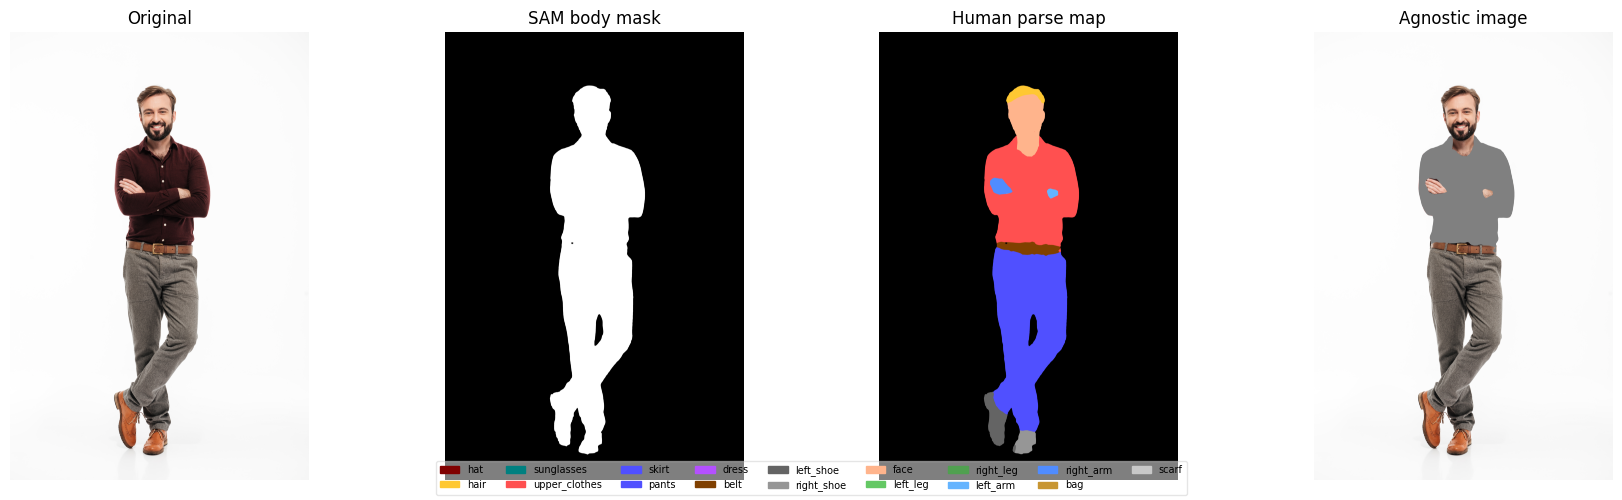


Region breakdown:
  Region                 Pixels  Coverage
  ----------------------------------------
  background           30459873     84.3%
  hair                    89173      0.2%
  upper_clothes         2040993      5.6%
  pants                 2572549      7.1%
  belt                   159903      0.4%
  left_shoe              193353      0.5%
  right_shoe             105234      0.3%
  face                   440174      1.2%
  left_arm                22182      0.1%
  right_arm               68886      0.2%


In [13]:
# Visualise all outputs
show_segmentation_results(result)

## Step 8 — Quality checks

Before saving, verify the agnostic image looks correct:
- ✓ Face, hair, hands, legs should be **unchanged**
- ✓ Clothing region should be **neutral grey**
- ✓ Background should be **unchanged**
- ✗ If arms are fully erased — adjust `erase_labels` to remove `14, 15`
- ✗ If clothing is not fully erased — check parse map for missed regions

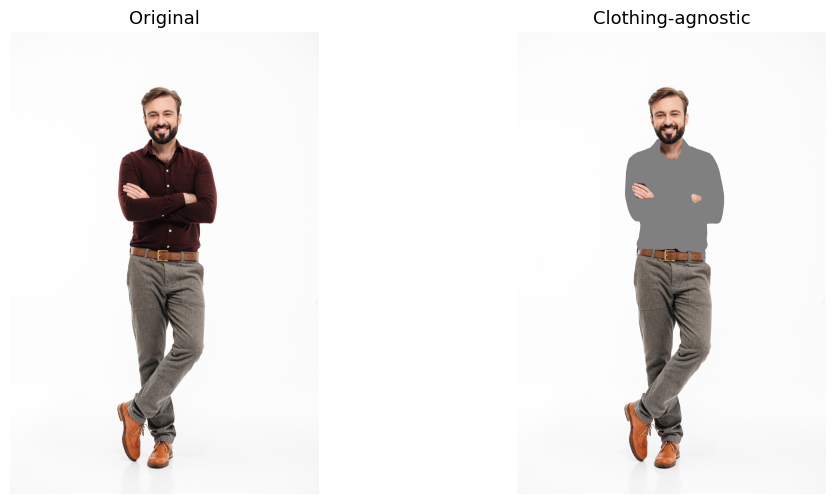

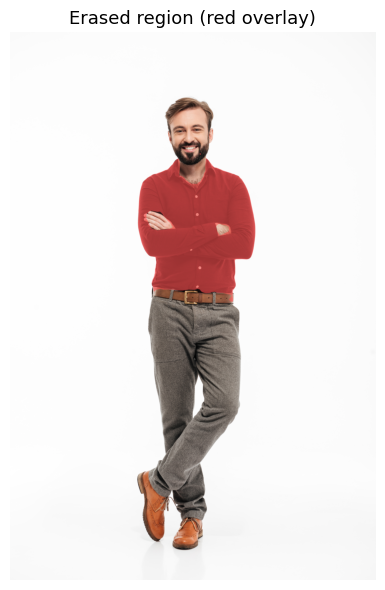

Erased region coverage: 5.8% of image
Expected range: 10–35% for a typical standing person with upper clothing


In [14]:
# Side-by-side detail comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(result['image_rgb'])
axes[0].set_title('Original', fontsize=13)
axes[0].axis('off')

axes[1].imshow(result['agnostic_img'])
axes[1].set_title('Clothing-agnostic', fontsize=13)
axes[1].axis('off')

# Overlay the erase mask as a red tint on the original
overlay = result['image_rgb'].copy()
overlay[result['agnostic_mask'] == 255] = (
    overlay[result['agnostic_mask'] == 255] * 0.4 +
    np.array([255, 80, 80]) * 0.6
).astype(np.uint8)

fig2, ax2 = plt.subplots(1, 1, figsize=(5, 6))
ax2.imshow(overlay)
ax2.set_title('Erased region (red overlay)', fontsize=13)
ax2.axis('off')

plt.tight_layout()
plt.show()

# Agnostic mask coverage
coverage = np.sum(result['agnostic_mask'] == 255) / result['agnostic_mask'].size * 100
print(f"Erased region coverage: {coverage:.1f}% of image")
print("Expected range: 10–35% for a typical standing person with upper clothing")

## Step 9 — Save all outputs

In [15]:
stem = Path(TEST_IMAGE_PATH).stem

# 1. Body mask
body_mask_path = OUTPUT_DIR / f"{stem}_body_mask.png"
cv2.imwrite(str(body_mask_path), result['body_mask'])
print(f"Body mask       : {body_mask_path}")

# 2. Parse map (integer labels — for training)
parse_path = OUTPUT_DIR / f"{stem}_parse.png"
cv2.imwrite(str(parse_path), result['parse_map'])
print(f"Parse map       : {parse_path}")

# 3. Parse map colour visualisation (for debugging)
parse_color_path = OUTPUT_DIR / f"{stem}_parse_color.png"
parse_color_bgr  = cv2.cvtColor(parse_map_to_color(result['parse_map']), cv2.COLOR_RGB2BGR)
cv2.imwrite(str(parse_color_path), parse_color_bgr)
print(f"Parse (colour)  : {parse_color_path}")

# 4. Agnostic image
agnostic_path = OUTPUT_DIR / f"{stem}_agnostic.jpg"
agnostic_bgr  = cv2.cvtColor(result['agnostic_img'], cv2.COLOR_RGB2BGR)
cv2.imwrite(str(agnostic_path), agnostic_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
print(f"Agnostic image  : {agnostic_path}")

# 5. Agnostic mask (binary)
agnostic_mask_path = OUTPUT_DIR / f"{stem}_agnostic_mask.png"
cv2.imwrite(str(agnostic_mask_path), result['agnostic_mask'])
print(f"Agnostic mask   : {agnostic_mask_path}")

print("\n✓ All segmentation outputs saved.")

Body mask       : outputs/segmentation/test-image_body_mask.png
Parse map       : outputs/segmentation/test-image_parse.png
Parse (colour)  : outputs/segmentation/test-image_parse_color.png
Agnostic image  : outputs/segmentation/test-image_agnostic.jpg
Agnostic mask   : outputs/segmentation/test-image_agnostic_mask.png

✓ All segmentation outputs saved.


## Step 10 — Batch processing

In [16]:
def batch_segment(image_dir, pose_json_dir, output_dir, extensions=('.jpg', '.jpeg', '.png')):
    """
    Run segmentation on all images in a directory.
    Expects a matching *_keypoints.json in pose_json_dir for each image.

    Args:
        image_dir    : folder with person images
        pose_json_dir: folder with Module 1 keypoint JSONs
        output_dir   : where to save segmentation outputs
    """
    image_dir     = Path(image_dir)
    pose_json_dir = Path(pose_json_dir)
    output_dir    = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in extensions])
    print(f"Found {len(image_paths)} images")

    failed = []

    for i, img_path in enumerate(image_paths):
        stem      = img_path.stem
        json_path = pose_json_dir / f"{stem}_keypoints.json"

        if not json_path.exists():
            print(f"  SKIP {stem} — no keypoint JSON found")
            failed.append(stem)
            continue

        try:
            keypoints = load_keypoints_from_json(json_path)
            result    = segmentor.process(img_path, keypoints)

            # Save outputs
            cv2.imwrite(str(output_dir / f"{stem}_body_mask.png"),     result['body_mask'])
            cv2.imwrite(str(output_dir / f"{stem}_parse.png"),         result['parse_map'])
            cv2.imwrite(str(output_dir / f"{stem}_agnostic_mask.png"), result['agnostic_mask'])
            agnostic_bgr = cv2.cvtColor(result['agnostic_img'], cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(output_dir / f"{stem}_agnostic.jpg"), agnostic_bgr,
                        [cv2.IMWRITE_JPEG_QUALITY, 95])

            if (i + 1) % 20 == 0:
                print(f"  Processed {i+1}/{len(image_paths)}")

        except Exception as e:
            print(f"  ERROR on {stem}: {e}")
            failed.append(stem)

    print(f"\nDone. Success: {len(image_paths) - len(failed)} | Failed: {len(failed)}")

# Example — uncomment when dataset is ready
# batch_segment(
#     image_dir     = "data/viton_hd/train/image",
#     pose_json_dir = "data/viton_hd/train/openpose_json",
#     output_dir    = "data/viton_hd/train/image-parse"
# )

---
## Summary

| Output file | Content | Used by |
|---|---|---|
| `*_body_mask.png` | SAM precise person boundary | Mask garment warping region |
| `*_parse.png` | Per-pixel ATR label (0–17) | HR-VITON dataloader |
| `*_agnostic.jpg` | Person with clothes erased | cGAN generator input |
| `*_agnostic_mask.png` | Binary clothing erase region | Composite blending mask |

**Next module:** Garment warping — uses TPS transformation to warp the flat garment image onto the body shape defined by the pose skeleton and agnostic mask.